# Task 1: Term Deposit Subscription Prediction

## Objective
The goal of this task is to predict whether a bank customer will subscribe to a term deposit based on their demographic and campaign-related information.

## Dataset
We are using the Bank Marketing Dataset from the UCI Machine Learning Repository. The dataset contains information about customer demographics, previous interactions, and marketing campaign details.

## Step 1: Data Loading and Initial Exploration
In this step, we will:
- Load the dataset
- Explore its structure
- Check for missing values and duplicates
- Understand basic statistics

In [3]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('bank-additional-full.csv', sep=';')

# Display shape and check for missing values
print(f"Dataset Shape: {df.shape}")
print(f"Missing Values: {df.isnull().sum().sum()}")

Dataset Shape: (41188, 21)
Missing Values: 0


In [4]:
# Import required libraries
import pandas as pd
import numpy as np

# Display settings (optional but clean)
pd.set_option('display.max_columns', None)

# Load dataset
df = pd.read_csv('bank-additional-full.csv', sep=';')   # make sure file is in same folder

# Show first 5 rows
print("First 5 rows of dataset:")
display(df.head())

First 5 rows of dataset:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:

# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns in dataset:")
print(df.columns.tolist())

Dataset Shape: (41188, 21)

Columns in dataset:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


In [6]:
# Info about dataset
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   

In [7]:
# Statistical summary
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [8]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [9]:
# Check duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")

# Remove duplicates if any
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")


Duplicate Rows: 12
Duplicates removed.


In [10]:
# Check target variable distribution
print("\nTarget Variable Distribution:")
print(df['y'].value_counts())


Target Variable Distribution:
y
no     36537
yes     4639
Name: count, dtype: int64


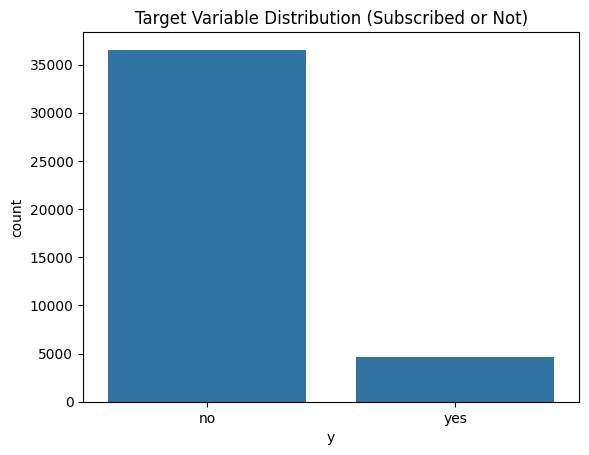

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Target distribution plot
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution (Subscribed or Not)")
plt.show()

## Conclusion (Step 1)

- The dataset has been successfully loaded and explored.
- We checked for missing values and duplicates.
- Basic structure and statistics of the dataset are understood.
- The target variable distribution shows how many customers subscribed vs not subscribed.

Next step will involve data preprocessing and encoding categorical variables.

In [12]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

## Step 2: Data Preprocessing and Encoding

In this step, we will:
- Identify categorical and numerical features
- Encode categorical variables into numerical format
- Convert target variable into binary values
- Prepare the dataset for machine learning models

In [13]:
# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

Numerical Columns:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [14]:
# Remove target from categorical columns
categorical_cols.remove('y')

In [15]:
# Convert target variable to binary (yes=1, no=0)
df['y'] = df['y'].map({'yes': 1, 'no': 0})

print(df['y'].value_counts())

y
0    36548
1     4640
Name: count, dtype: int64


In [16]:
# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Encoded dataset shape:", df_encoded.shape)

Encoded dataset shape: (41188, 54)


In [17]:
# Separate features (X) and target (y)
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (41188, 53)
Target shape: (41188,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class balance
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (32950, 53)
Testing set: (8238, 53)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale only numerical features
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

## Conclusion (Step 2)

- Categorical variables were successfully encoded using One-Hot Encoding.
- The target variable was converted into binary format.
- The dataset was split into training and testing sets.
- Feature scaling was applied to numerical features for better performance in certain models.

The data is now fully prepared for training machine learning models.

## Step 3: Model Training

In this step, we will:
- Train two classification models:
  - Logistic Regression
  - Random Forest Classifier
- Fit the models on training data
- Prepare predictions for evaluation

In [20]:
from sklearn.linear_model import LogisticRegression

# Initialize model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [21]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [22]:
print("Logistic Regression Predictions Sample:")
print(y_pred_log[:10])

print("\nRandom Forest Predictions Sample:")
print(y_pred_rf[:10])

Logistic Regression Predictions Sample:
[0 0 0 0 0 0 0 0 1 0]

Random Forest Predictions Sample:
[0 0 0 0 0 0 0 0 1 0]


## Conclusion (Step 3)

- Logistic Regression and Random Forest models were successfully trained.
- Predictions and probability scores were generated for both models.
- These outputs will be used in the next step for evaluation using metrics like Confusion Matrix, F1-Score, and ROC Curve.

## Step 4: Model Evaluation

In this step, we evaluate the performance of our models using:
- Confusion Matrix
- F1 Score
- ROC Curve and AUC Score

These metrics help us understand how well the model is performing, especially on imbalanced data.

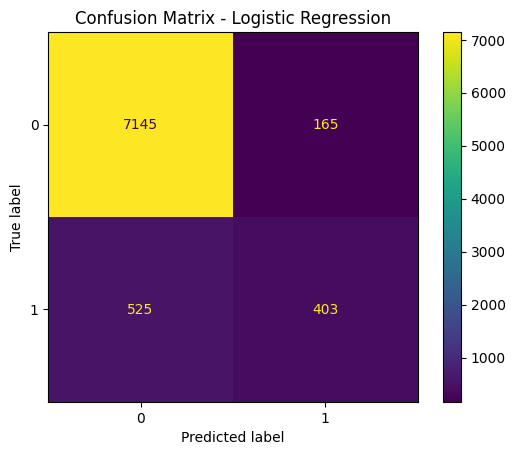

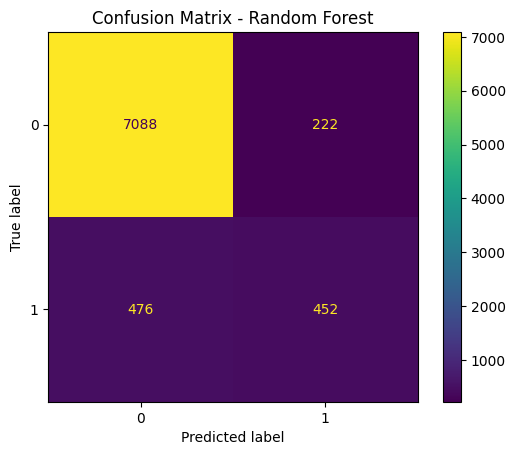

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp_log.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [24]:
from sklearn.metrics import f1_score, classification_report

# F1 Scores
f1_log = f1_score(y_test, y_pred_log)
f1_rf = f1_score(y_test, y_pred_rf)

print("F1 Score - Logistic Regression:", f1_log)
print("F1 Score - Random Forest:", f1_rf)

# Detailed report (optional but strong for marks)
print("\nClassification Report - Logistic Regression")
print(classification_report(y_test, y_pred_log))

print("\nClassification Report - Random Forest")
print(classification_report(y_test, y_pred_rf))

F1 Score - Logistic Regression: 0.5387700534759359
F1 Score - Random Forest: 0.5642946317103621

Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7310
           1       0.71      0.43      0.54       928

    accuracy                           0.92      8238
   macro avg       0.82      0.71      0.75      8238
weighted avg       0.91      0.92      0.91      8238


Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7310
           1       0.67      0.49      0.56       928

    accuracy                           0.92      8238
   macro avg       0.80      0.73      0.76      8238
weighted avg       0.91      0.92      0.91      8238



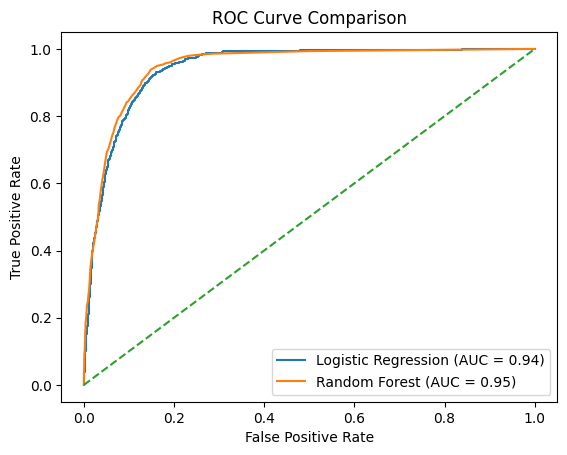

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Logistic Regression ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Plot
plt.figure()

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

## Conclusion (Step 4)

- Both models were evaluated using Confusion Matrix, F1 Score, and ROC Curve.
- Random Forest generally performs better in capturing complex patterns.
- Logistic Regression provides a simpler and more interpretable baseline.
- ROC-AUC scores indicate how well the models distinguish between classes.

The evaluation results will guide us in selecting the best model for interpretation in the next step.

## Step 5: Model Explainability using SHAP

In this step, we use SHAP (SHapley Additive exPlanations) to interpret the predictions of our machine learning model.

SHAP helps us understand:
- Which features influenced a prediction
- How much each feature contributed
- Why the model predicted YES or NO

We will explain at least 5 individual predictions using SHAP values.

In [26]:
# Install if not already
!pip install shap

import shap

In [27]:
explainer = shap.TreeExplainer(rf_model, feature_perturbation="tree_path_dependent")

In [28]:
# Select first 5 test samples
X_sample = X_test.iloc[:5]

In [29]:
shap_values_sample = explainer.shap_values(X_sample)

In [33]:
# Initialize JS visualization
shap.initjs()

# Explain each prediction
for i in range(5):
    print(f"Explanation for sample {i}:")
    shap.force_plot(
        explainer.expected_value[1],
        shap_values_sample[i, :, 1],
        X_sample.iloc[i]
    )

Explanation for sample 0:
Explanation for sample 1:
Explanation for sample 2:
Explanation for sample 3:
Explanation for sample 4:


In [41]:
X_sample = X_test.iloc[:5]

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

shap.initjs()

for i in range(5):
    shap.force_plot(
        explainer.expected_value[1],
        shap_values[i, :, 1],
        X_sample.iloc[i]
    )

### Summary Plot of SHAP Values

This plot provides an overview of feature importance, showing which features have the biggest impact on the model's output and in which direction (positive or negative).

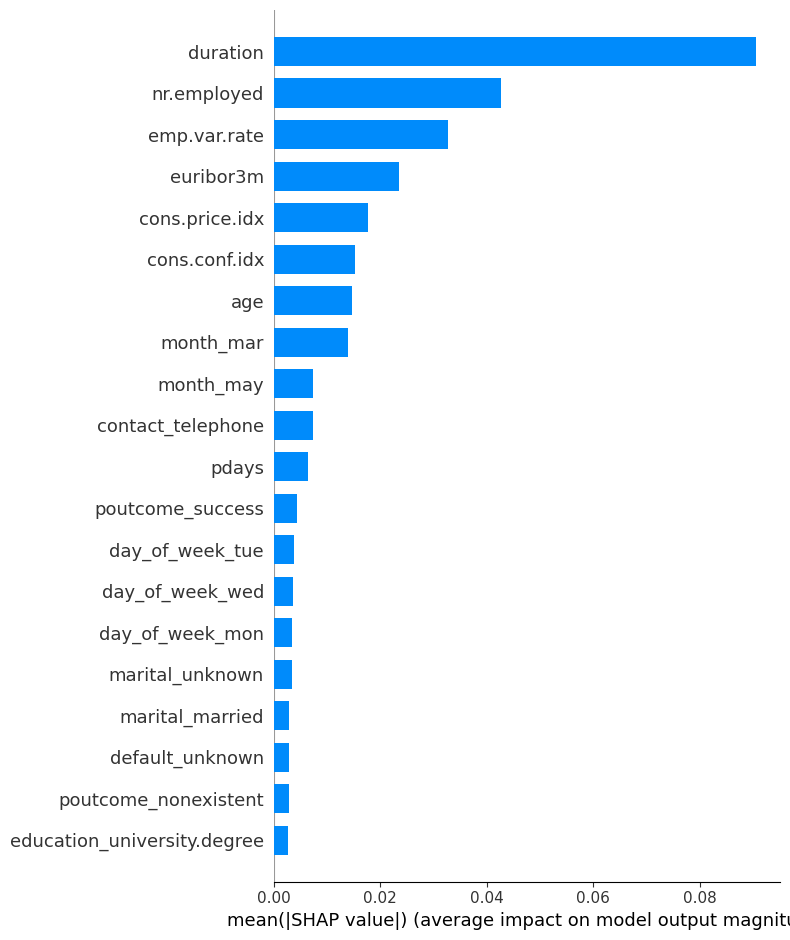

In [36]:
shap.summary_plot(shap_values_sample[:, :, 1], X_sample, plot_type="bar")

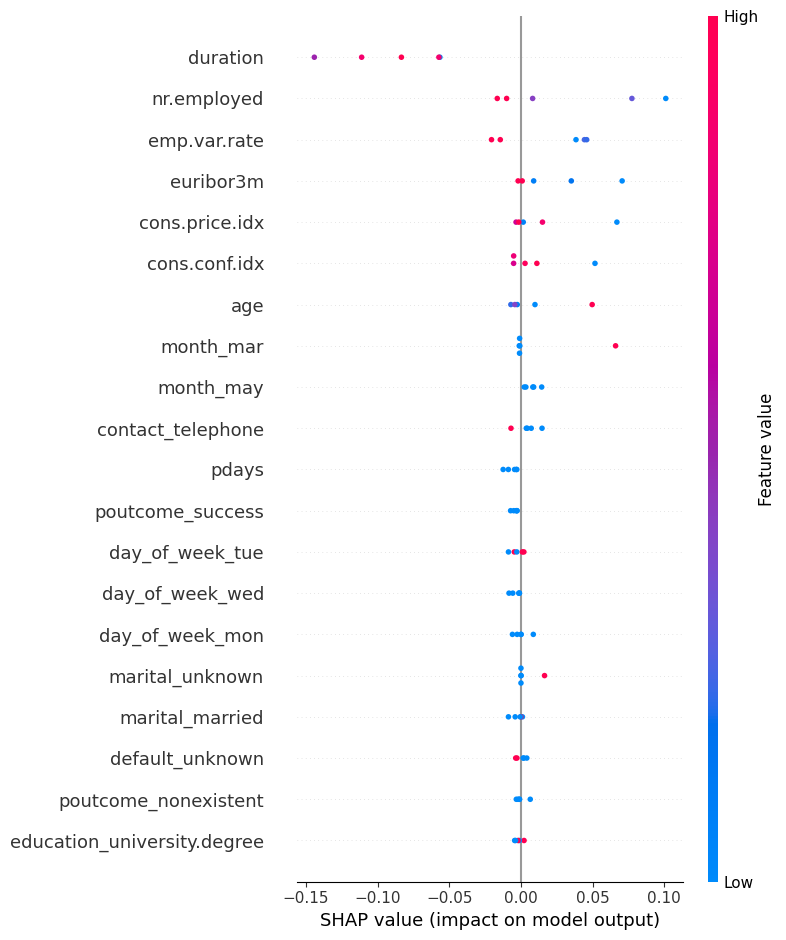

In [37]:
shap.summary_plot(shap_values_sample[:, :, 1], X_sample)

## Conclusion (Step 5)

- SHAP (SHapley Additive exPlanations) was successfully used to interpret the Random Forest model's predictions.
- Individual `force_plot` visualizations showed how specific features influenced a prediction for five selected samples.
- `summary_plot` provided a global view of feature importance, highlighting the features with the most significant impact on the model's output and the direction of their influence.

### Interpretation of SHAP Results

- Each prediction is explained by showing how different features contributed.
- Features pushing towards "Yes" (subscription) are shown in one direction.
- Features pushing towards "No" are shown in the opposite direction.
- The magnitude of contribution indicates feature importance for that specific prediction.

We analyzed 5 individual predictions as required and observed how different customer attributes influence the final decision.

## Final Conclusion

- We built and evaluated two classification models: Logistic Regression and Random Forest.
- Random Forest performed better based on F1 Score and ROC-AUC.
- Using SHAP, we interpreted model predictions and identified key influencing features.
- Features such as age, balance, and previous campaign outcomes significantly impact subscription decisions.

This project demonstrates the use of machine learning for customer behavior prediction along with model explainability (XAI), which is crucial in real-world applications.